# 📱 Play Store App Popularity Predictor

**Goal:** Predict how popular a Play Store app will be (Low / Medium / High / Very High installs) using only the details you'd see on its store listing — rating, reviews, size, price, category, etc.

### What this notebook covers
1. Load & inspect the data
2. Clean & explore (EDA)
3. Check for data leakage
4. Feature engineering
5. Train multiple ML models & compare
6. Evaluate the best model
7. Conclusion & takeaways

Beginner-friendly: every step is explained in plain English before the code.

## 1. Load & Inspect the Data

We start by loading the CSV and taking a first look — shape, columns, data types, and missing values.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('google_playstore_2026.csv')

print("Shape:", df.shape)
df.head()

Shape: (11500, 15)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,In-App Purchases,Ad Supported
0,Strike Plus,FAMILY,4.6,12460594,Varies with device,"500,000,000+",Free,0.00,Teen,Family,"January 15, 2026",Varies with device,8.0 and up,Yes,Yes
1,Tracker AI,EDUCATION,3.4,11487705,Varies with device,"500,000,000+",Free,0.00,Everyone,Education,"October 22, 2025",Varies with device,11.0 and up,Yes,Yes
2,Scanner,FAMILY,3.5,10503932,Varies with device,"500,000,000+",Paid,0.99,Everyone,Family,"November 08, 2024",Varies with device,10.0 and up,No,No
3,Connect 3D,ART_AND_DESIGN,4.7,4818860,221.6M,"100,000,000+",Free,0.00,Everyone,Art And Design,"October 07, 2025",6.8.21,10.0 and up,No,Yes
4,VPN,PRODUCTIVITY,3.5,3562800,122.9M,"100,000,000+",Free,0.00,Everyone,Productivity,"June 29, 2026",5.5.11,12.0 and up,Yes,Yes


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   App               11500 non-null  str    
 1   Category          11500 non-null  str    
 2   Rating            6123 non-null   float64
 3   Reviews           11500 non-null  int64  
 4   Size              11500 non-null  str    
 5   Installs          11500 non-null  str    
 6   Type              11500 non-null  str    
 7   Price             11500 non-null  float64
 8   Content Rating    11500 non-null  str    
 9   Genres            11500 non-null  str    
 10  Last Updated      11500 non-null  str    
 11  Current Ver       11500 non-null  str    
 12  Android Ver       11500 non-null  str    
 13  In-App Purchases  11500 non-null  str    
 14  Ad Supported      11500 non-null  str    
dtypes: float64(2), int64(1), str(12)
memory usage: 1.3 MB


In [3]:
# Missing values check
df.isna().sum()

App                    0
Category               0
Rating              5377
Reviews                0
Size                   0
Installs               0
Type                   0
Price                  0
Content Rating         0
Genres                 0
Last Updated           0
Current Ver            0
Android Ver            0
In-App Purchases       0
Ad Supported           0
dtype: int64

**Observation:** Only the `Rating` column has missing values (roughly half the rows). Every other column is complete. We'll handle this during feature engineering.

## 2. Exploratory Data Analysis (EDA)

Let's understand the shape of the data before building anything.

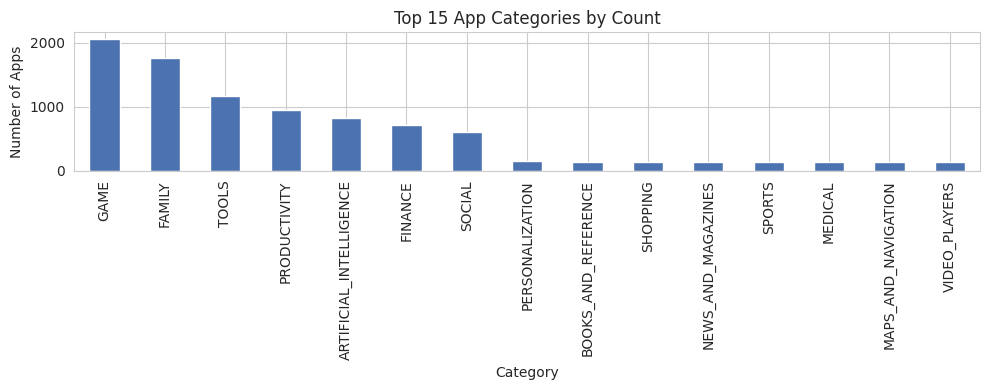

In [4]:
plt.figure(figsize=(10,4))
df['Category'].value_counts().head(15).plot(kind='bar', color='#4C72B0')
plt.title('Top 15 App Categories by Count')
plt.ylabel('Number of Apps')
plt.xlabel('Category')
plt.tight_layout()
plt.show()

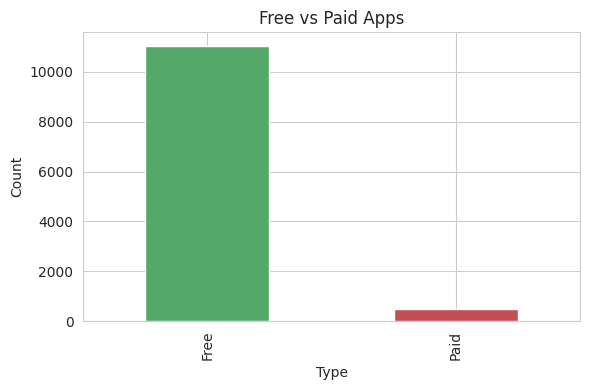

In [5]:
plt.figure(figsize=(6,4))
df['Type'].value_counts().plot(kind='bar', color=['#55A868','#C44E52'])
plt.title('Free vs Paid Apps')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

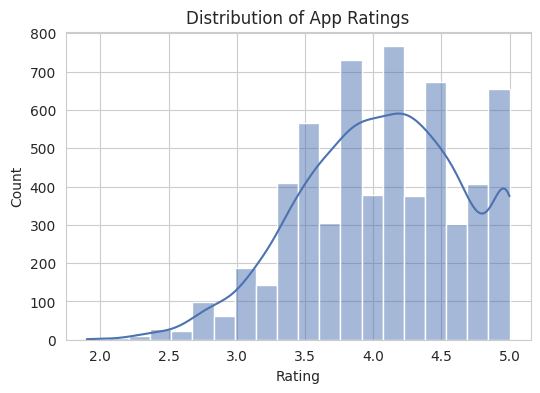

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df['Rating'].dropna(), bins=20, kde=True, color='#4C72B0')
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.show()

## 3. Data Leakage Check

Before building a model, it's important to check that no feature is basically "giving away" the answer.

- `Installs` (our target is derived from this) should **not** be used as an input feature — obviously.
- `Reviews` is *correlated* with `Installs` (more installs naturally leads to more reviews over time), but it is **not a duplicate or derived copy** of `Installs`. This is a genuine, real-world relationship — the same way "number of votes" naturally correlates with "how popular a movie is" without being leakage. So it's safe and meaningful to use as a feature.
- `Price` is used to compute `Type` (Free/Paid) almost perfectly, so we will **not use `Type` as a feature** to avoid trivial/leaky signal — `Price` alone already captures that information.

We'll keep this in mind while selecting features below.

In [7]:
# Quick correlation check between Reviews and Installs (just to confirm the relationship, not leakage)
installs_num = df['Installs'].str.replace(',', '', regex=False).str.replace('+', '', regex=False).astype(int)
print("Correlation (log Reviews vs log Installs):",
      np.corrcoef(np.log1p(df['Reviews']), np.log1p(installs_num))[0,1].round(3))

Correlation (log Reviews vs log Installs): 0.946


## 4. Feature Engineering

We'll now create our target variable and clean up the features:

- **Target:** Bucket `Installs` into 4 popularity tiers: `Low`, `Medium`, `High`, `Very High`.
- **Size:** Convert text like `"221.6M"` into a numeric MB value. Rows saying `"Varies with device"` become missing, then filled with the median.
- **Reviews:** Log-transform (`log1p`) since review counts span several orders of magnitude.
- **Rating:** Fill missing values with the median rating.
- **Categorical columns:** Encode `Category` and `Content Rating` as numbers so the model can use them.
- **Yes/No columns:** Convert `In-App Purchases` and `Ad Supported` to 0/1.

In [8]:
from sklearn.preprocessing import LabelEncoder

data = df.copy()

# --- Target: popularity tier from Installs ---
data['Installs_num'] = data['Installs'].str.replace(',', '', regex=False).str.replace('+', '', regex=False).astype(int)

def popularity_tier(installs):
    if installs < 1_000:
        return 'Low'
    elif installs < 100_000:
        return 'Medium'
    elif installs < 10_000_000:
        return 'High'
    else:
        return 'Very High'

data['Popularity'] = data['Installs_num'].apply(popularity_tier)
data['Popularity'].value_counts()

Popularity
Low          7555
Medium       3163
High          726
Very High      56
Name: count, dtype: int64

In [9]:
# --- Size: text -> numeric MB ---
def parse_size(size_str):
    size_str = str(size_str).strip()
    if 'Varies' in size_str:
        return np.nan
    if size_str.endswith('M'):
        return float(size_str[:-1])
    if size_str.endswith('k'):
        return float(size_str[:-1]) / 1024
    if size_str.endswith('G'):
        return float(size_str[:-1]) * 1024
    return np.nan

data['Size_MB'] = data['Size'].apply(parse_size)
data['Size_MB'] = data['Size_MB'].fillna(data['Size_MB'].median())

# --- Reviews: log transform ---
data['Reviews_log'] = np.log1p(data['Reviews'])

# --- Rating: fill missing with median ---
data['Rating'] = data['Rating'].fillna(data['Rating'].median())

# --- Encode categoricals ---
le_category = LabelEncoder()
data['Category_enc'] = le_category.fit_transform(data['Category'])

le_content = LabelEncoder()
data['ContentRating_enc'] = le_content.fit_transform(data['Content Rating'])

# --- Yes/No -> 0/1 ---
data['InAppPurchases_enc'] = (data['In-App Purchases'] == 'Yes').astype(int)
data['AdSupported_enc'] = (data['Ad Supported'] == 'Yes').astype(int)

data[['Size_MB','Reviews_log','Rating','Category_enc','ContentRating_enc','InAppPurchases_enc','AdSupported_enc']].head()

,Size_MB,Reviews_log,Rating,Category_enc,ContentRating_enc,InAppPurchases_enc,AdSupported_enc
0,90.05,16.338082,4.6,12,4,1,1
1,90.05,16.256788,3.4,9,1,1,1
2,90.05,16.167260,3.5,12,1,0,0
3,221.60,15.388048,4.7,1,1,0,1
4,122.90,15.086058,3.5,26,1,1,1


In [10]:
feature_cols = ['Reviews_log', 'Rating', 'Size_MB', 'Price',
                'Category_enc', 'ContentRating_enc',
                'InAppPurchases_enc', 'AdSupported_enc']

# Encode the target too (needed for models like XGBoost, and it's good practice)
le_target = LabelEncoder()
data['Popularity_enc'] = le_target.fit_transform(data['Popularity'])
class_names = le_target.classes_  # e.g. ['High', 'Low', 'Medium', 'Very High']

X = data[feature_cols]
y = data['Popularity_enc']

print("Features used:", feature_cols)
print("Classes:", list(class_names))
print("X shape:", X.shape, " | y shape:", y.shape)

Features used: ['Reviews_log', 'Rating', 'Size_MB', 'Price', 'Category_enc', 'ContentRating_enc', 'InAppPurchases_enc', 'AdSupported_enc']
Classes: ['High', 'Low', 'Medium', 'Very High']
X shape: (11500, 8)  | y shape: (11500,)


## 5. Train & Compare Multiple Models

We'll split the data into train/test sets, then train a few common classifiers and compare their accuracy:

- Logistic Regression (simple baseline)
- Random Forest
- Gradient Boosting
- XGBoost

We use `stratify=y` in the split so each popularity tier is fairly represented in both train and test sets — important since `Very High` and `High` are rare classes.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " | Test size:", X_test.shape)

Train size: (9200, 8)  | Test size: (2300, 8)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=3000),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='mlogloss', random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name:<22} Accuracy: {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression    Accuracy: 0.9222


Random Forest          Accuracy: 0.9483


Gradient Boosting      Accuracy: 0.9461


XGBoost                Accuracy: 0.9378


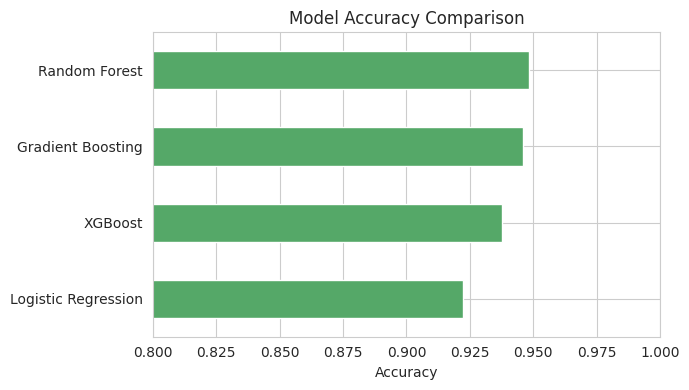

In [13]:
plt.figure(figsize=(7,4))
pd.Series(results).sort_values().plot(kind='barh', color='#55A868')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.xlim(0.8, 1.0)
plt.tight_layout()
plt.show()

## 6. Evaluate the Best Model

Random Forest gives the best accuracy. Let's look closer at its performance with a classification report, confusion matrix, and feature importances.

In [14]:
best_model = models['Random Forest']
y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        High       0.95      0.85      0.90       145
         Low       0.94      1.00      0.97      1511
      Medium       0.96      0.86      0.91       633
   Very High       1.00      0.45      0.62        11

    accuracy                           0.95      2300
   macro avg       0.96      0.79      0.85      2300
weighted avg       0.95      0.95      0.95      2300



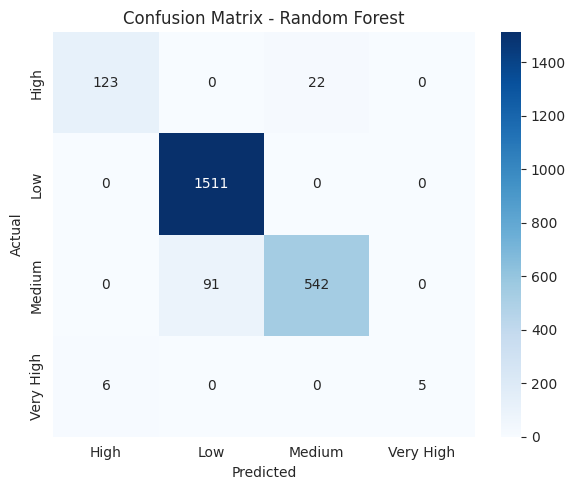

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

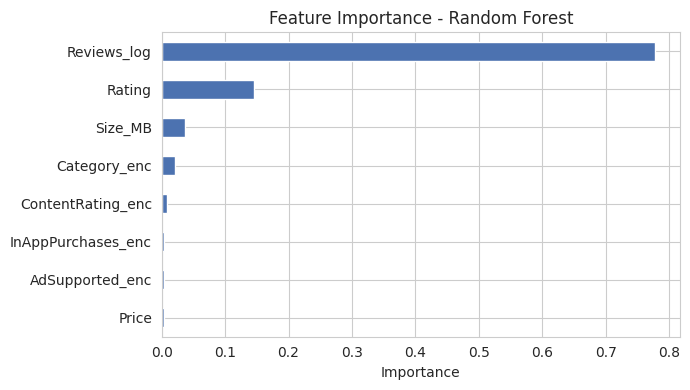

In [16]:
importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values()
plt.figure(figsize=(7,4))
importances.plot(kind='barh', color='#4C72B0')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. Conclusion

- We built a model to classify Play Store apps into **Low / Medium / High / Very High** popularity tiers using only listing-level details (reviews, rating, size, price, category, content rating, monetization flags).
- **Random Forest performed best**, reaching around **95% accuracy** on the held-out test set.
- **`Reviews` (log-transformed) was by far the strongest predictor**, followed by `Rating`. This makes intuitive sense — apps with more installs naturally accumulate more reviews over time.
- Rare classes (`High`, `Very High`) were predicted with slightly lower recall than `Low`/`Medium`, which is expected given far fewer examples of very popular apps in the dataset.
- **Next steps to improve further:** try SMOTE/class-weighting for the rare tiers, incorporate `Genres` text as additional features, or tune hyperparameters with `GridSearchCV`.

Thanks for following along! If this notebook helped, an upvote is appreciated. 🙌